Files loaded successfully.
Model R2 Score: 0.0370


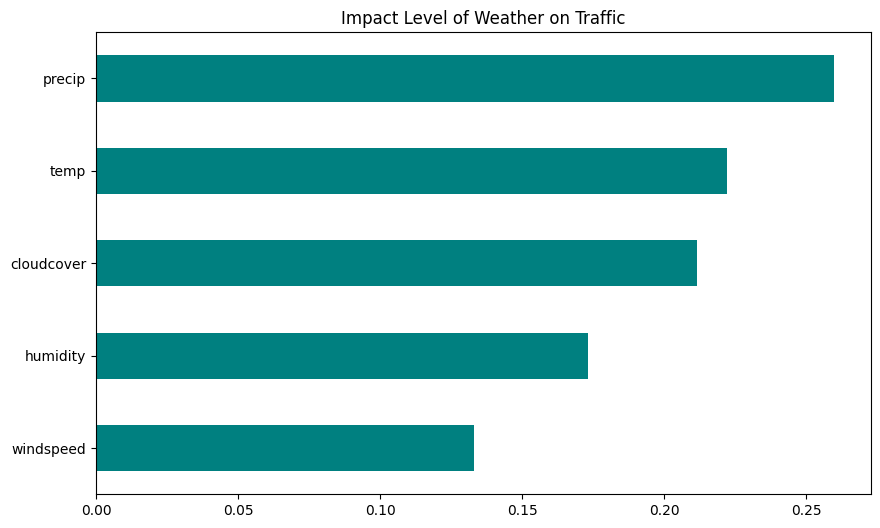

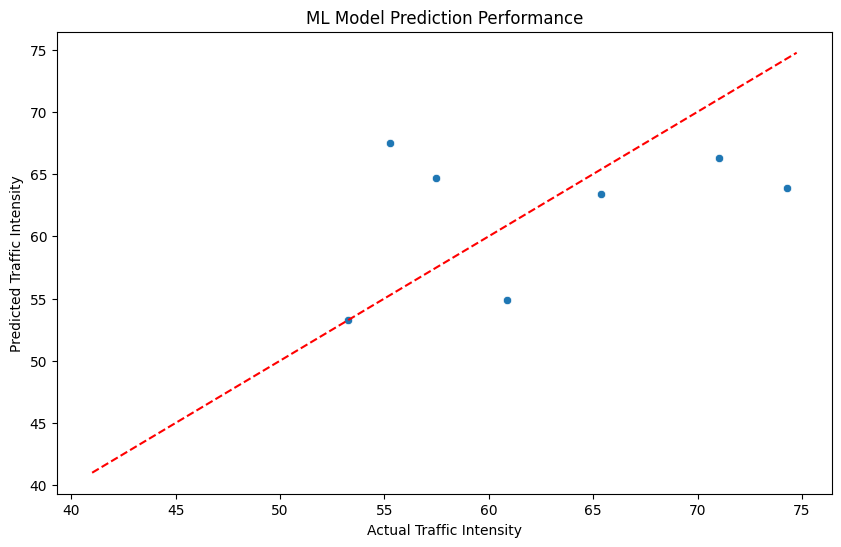

Process completed. 'analysis_feature_importance.png', 'analysis_model_performance.png' and 'dsa210_final_output.csv' have been created.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


try:
    weather_df = pd.read_csv('weather_data.csv')
    traffic_df = pd.read_csv('traffic_density_january_2025_daily.csv')
    print("Files loaded successfully.")
except FileNotFoundError:
    print("Error: CSV files not found. Please check the file names.")


if 'datetime' in weather_df.columns:
    weather_df = weather_df.rename(columns={'datetime': 'date'})


weather_df['date'] = pd.to_datetime(weather_df['date'])
traffic_df['date'] = pd.to_datetime(traffic_df['date'])


merged_df = pd.merge(traffic_df, weather_df, on='date')


merged_df = merged_df.dropna(subset=['temp', 'humidity', 'precip', 'windspeed', 'cloudcover', 'traffic_intensity_avg'])

features = ['temp', 'humidity', 'precip', 'windspeed', 'cloudcover']
X = merged_df[features]
y = merged_df['traffic_intensity_avg']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print(f"Model R2 Score: {r2_score(y_test, y_pred):.4f}")


plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Impact Level of Weather on Traffic')
plt.savefig('analysis_feature_importance.png')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel('Actual Traffic Intensity')
plt.ylabel('Predicted Traffic Intensity')
plt.title('ML Model Prediction Performance')
plt.savefig('analysis_model_performance.png')
plt.show()


merged_df.to_csv('dsa210_final_output.csv', index=False)
print("Process completed. 'analysis_feature_importance.png', 'analysis_model_performance.png' and 'dsa210_final_output.csv' have been created.")